In [1]:
!pip install -q pandas matplotlib wordcloud ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.8 MB/s eta 0:00:00


In [2]:

import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import display, HTML
import ipywidgets as widgets

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [3]:
FILLER_WORDS = {
    "um",
    "uh",
    "er",
    "erm",
    "hmm",
    "like",
    "actually",
    "basically",
    "literally",
    "you know",
    "i mean",
    "sort of",
    "kind of",
    "well",
    "so"
}

print("Number of filler words/phrases:", len(FILLER_WORDS))
print(FILLER_WORDS)

Number of filler words/phrases: 15
{'uh', 'hmm', 'like', 'erm', 'literally', 'you know', 'i mean', 'kind of', 'sort of', 'actually', 'well', 'er', 'basically', 'um', 'so'}


In [4]:
def detect_filler_words(text):
    """
    Detect filler words and phrases from user-provided text.
    """

    text_lower = text.lower()

    # Normalize spaces
    text_lower = re.sub(r"\s+", " ", text_lower).strip()

    counts = Counter()

    # Check multi-word phrases first
    for filler in sorted(FILLER_WORDS, key=len, reverse=True):
        pattern = r"\b" + re.escape(filler) + r"\b"
        matches = re.findall(pattern, text_lower)

        if matches:
            counts[filler] = len(matches)

    total_words = len(re.findall(r"\b[\w']+\b", text_lower))
    total_fillers = sum(counts.values())

    if total_words > 0:
        filler_percentage = (total_fillers / total_words) * 100
    else:
        filler_percentage = 0

    return counts, total_words, total_fillers, filler_percentage

In [5]:
def calculate_fluency_score(filler_percentage):

    if filler_percentage == 0:
        return 100

    elif filler_percentage <= 2:
        return 95

    elif filler_percentage <= 4:
        return 85

    elif filler_percentage <= 6:
        return 75

    elif filler_percentage <= 10:
        return 60

    elif filler_percentage <= 15:
        return 45

    else:
        return 30


def get_feedback(score):

    if score >= 90:
        return "Excellent fluency! Your speech contains very few filler words."

    elif score >= 75:
        return "Good fluency. Try reducing a few unnecessary filler words."

    elif score >= 60:
        return "Moderate fluency. Consider pausing instead of using filler words."

    elif score >= 45:
        return "Your speech contains many filler words. Practice speaking more deliberately."

    else:
        return "High filler-word usage. Focus on pauses, preparation, and confident delivery."

In [6]:
def highlight_fillers(text):

    highlighted = text

    # Sort longest first so phrases are detected before individual words
    fillers_sorted = sorted(FILLER_WORDS, key=len, reverse=True)

    for filler in fillers_sorted:

        pattern = re.compile(
            r"\b" + re.escape(filler) + r"\b",
            re.IGNORECASE
        )

        highlighted = pattern.sub(
            lambda match:
            f'<span style="background-color:#ffcc80; '
            f'color:#8b0000; padding:2px 5px; '
            f'border-radius:4px; font-weight:bold;">'
            f'{match.group()}</span>',
            highlighted
        )

    return highlighted

In [7]:
def analyze_text(text):

    if not text.strip():
        print("⚠️ Please enter some text.")
        return

    counts, total_words, total_fillers, percentage = detect_filler_words(text)

    score = calculate_fluency_score(percentage)
    feedback = get_feedback(score)

    print("=" * 60)
    print("🤖 AI FILLER WORD DETECTION SYSTEM")
    print("=" * 60)

    print(f"\n📝 Total Words       : {total_words}")
    print(f"🔎 Filler Words      : {total_fillers}")
    print(f"📊 Filler Percentage : {percentage:.2f}%")
    print(f"⭐ Fluency Score     : {score}/100")

    print("\n💬 Feedback:")
    print(feedback)

    print("\n🔍 Filler Word Frequency:")

    if counts:
        df = pd.DataFrame(
            counts.items(),
            columns=["Filler Word", "Count"]
        ).sort_values(
            by="Count",
            ascending=False
        )

        display(df)

    else:
        print("✅ No filler words detected!")

    print("\n🎨 Highlighted Text:")

    display(
        HTML(
            f"""
            <div style="
                padding:15px;
                border-radius:10px;
                background:#f5f5f5;
                color:#222;
                font-size:16px;
                line-height:1.8;
            ">
            {highlight_fillers(text)}
            </div>
            """
        )
    )

In [8]:
sample_text = """
Um, I actually think this project is, like, very useful.
Basically, you know, we can use AI to detect filler words.
I mean, it can help students improve their speaking skills.
"""

analyze_text(sample_text)

🤖 AI FILLER WORD DETECTION SYSTEM

📝 Total Words       : 31
🔎 Filler Words      : 6
📊 Filler Percentage : 19.35%
⭐ Fluency Score     : 30/100

💬 Feedback:
High filler-word usage. Focus on pauses, preparation, and confident delivery.

🔍 Filler Word Frequency:


,Filler Word,Count
0,basically,1
1,you know,1
2,actually,1
3,i mean,1
4,like,1
5,um,1



🎨 Highlighted Text:


In [9]:
def plot_filler_words(text):

    counts, _, _, _ = detect_filler_words(text)

    if not counts:
        print("✅ No filler words found for visualization.")
        return

    df = pd.DataFrame(
        counts.items(),
        columns=["Filler Word", "Count"]
    ).sort_values(
        by="Count",
        ascending=True
    )

    plt.figure(figsize=(10, 5))

    plt.barh(
        df["Filler Word"],
        df["Count"]
    )

    plt.xlabel("Frequency")
    plt.ylabel("Filler Word")
    plt.title("Filler Word Frequency")

    plt.tight_layout()
    plt.show()

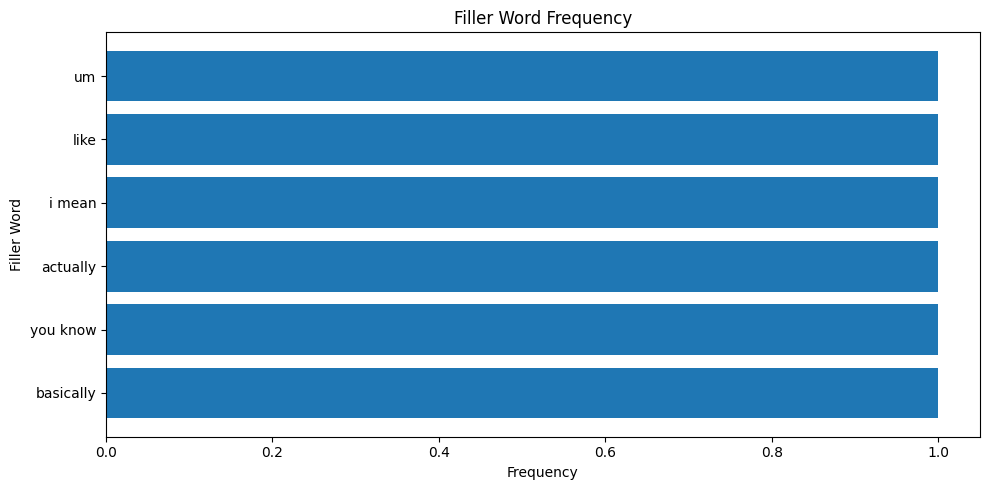

In [10]:
plot_filler_words(sample_text)

In [11]:
text_box = widgets.Textarea(
    value="",
    placeholder="Enter or paste your speech/transcript here...",
    description="Text:",
    layout=widgets.Layout(
        width="100%",
        height="200px"
    )
)

analyze_button = widgets.Button(
    description="🔍 Analyze Speech",
    button_style="primary",
    layout=widgets.Layout(
        width="200px",
        height="45px"
    )
)

output = widgets.Output()


def on_analyze_clicked(button):

    with output:
        output.clear_output()

        text = text_box.value

        if not text.strip():
            print("⚠️ Please enter some text first.")
            return

        analyze_text(text)

        print("\n📈 Filler Word Chart:")
        plot_filler_words(text)


analyze_button.on_click(on_analyze_clicked)

display(
    widgets.VBox([
        widgets.HTML(
            "<h2>🤖 AI Filler Word Detection System</h2>"
            "<p>Enter your speech or transcript below:</p>"
        ),
        text_box,
        analyze_button,
        output
    ])
)